In [11]:
import pandas as pd
import numpy as np

In [2]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [3]:
# import the PCC data
pcc_4S = pd.read_csv("pcc_4S.csv", index_col=0)
pcc_I = pd.read_csv("pcc_I.csv", index_col=0)
pcc_III = pd.read_csv("pcc_III.csv", index_col=0)
pcc_IV = pd.read_csv("pcc_IV.csv", index_col=0)
# pcc_NA = pd.read_csv("pcc_NA.csv", index_col=0)
pcc_4S

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.101876,-0.105444,0.294110,0.285490,0.043094,0.273760,0.154205,0.535308,0.574785,...,-0.214314,-0.225862,0.491546,0.099288,0.247549,-0.177206,0.227948,-0.268659,0.047149,-0.721479
DPM1,0.101876,1.000000,0.040753,0.366840,0.112091,-0.203120,0.277659,0.230100,0.012097,-0.223822,...,-0.017635,-0.288416,0.410572,0.095112,0.348526,0.411757,-0.319794,-0.130364,0.225836,-0.290486
SCYL3,-0.105444,0.040753,1.000000,0.378629,-0.077102,0.299282,0.164965,0.239981,-0.208912,0.051952,...,0.622151,0.586767,0.021289,0.030100,0.392734,0.130584,0.244455,0.441587,0.019297,0.122590
C1orf112,0.294110,0.366840,0.378629,1.000000,0.090887,0.202204,0.276277,0.408218,-0.028448,0.043607,...,0.243748,0.095764,0.304032,0.119730,0.447024,-0.121551,0.210028,0.290213,-0.177887,-0.509990
FGR,0.285490,0.112091,-0.077102,0.090887,1.000000,-0.117195,0.082018,-0.002028,0.309746,0.378912,...,0.061240,0.080967,0.612712,0.711971,0.284195,0.071398,0.207367,-0.222435,0.442745,-0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.177206,0.411757,0.130584,-0.121551,0.071398,-0.431935,-0.214156,-0.163260,0.100622,-0.076020,...,0.350383,0.075384,0.190224,0.019012,0.208961,1.000000,-0.613841,-0.308633,0.599359,0.277204
CYB561D2,0.227948,-0.319794,0.244455,0.210028,0.207367,0.558621,0.306613,0.189181,0.124066,0.351359,...,0.070697,0.309529,0.159834,0.172155,0.138332,-0.613841,1.000000,0.342137,-0.458748,-0.186283
CCDC7,-0.268659,-0.130364,0.441587,0.290213,-0.222435,0.542627,0.210271,0.254534,-0.347429,-0.078083,...,0.285602,0.507611,-0.117943,-0.003734,0.117266,-0.308633,0.342137,1.000000,-0.371967,0.101145


construct a weighted graph of edges based on 1-abs(PCC-value)

delete rows and columns with Inf entries, since those genes are deleted from the module. (already ensured the genes won't contribute to potential modules candidates by assuring only 1 connected component is >= 3 in the previous graph)

In [4]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from methods import Nlog_SWIM_pcc_to_distance

In [5]:
%pwd
%cd /home/jovyan/work/parameter_tuning/Nlog_SWIM/Cell/
%pwd

/home/jovyan/work/parameter_tuning/Nlog_SWIM/Cell


'/home/jovyan/work/parameter_tuning/Nlog_SWIM/Cell'

/home/jovyan/work/FUNCTIONS/methods.py:266: RuntimeWarning: divide by zero encountered in log
  nlog = -np.log(non_negative_normalized_pcc)


IGRAPH UNW- 12939 1322561 -- 
+ attr: name (v), weight (e)
graph is connected: False


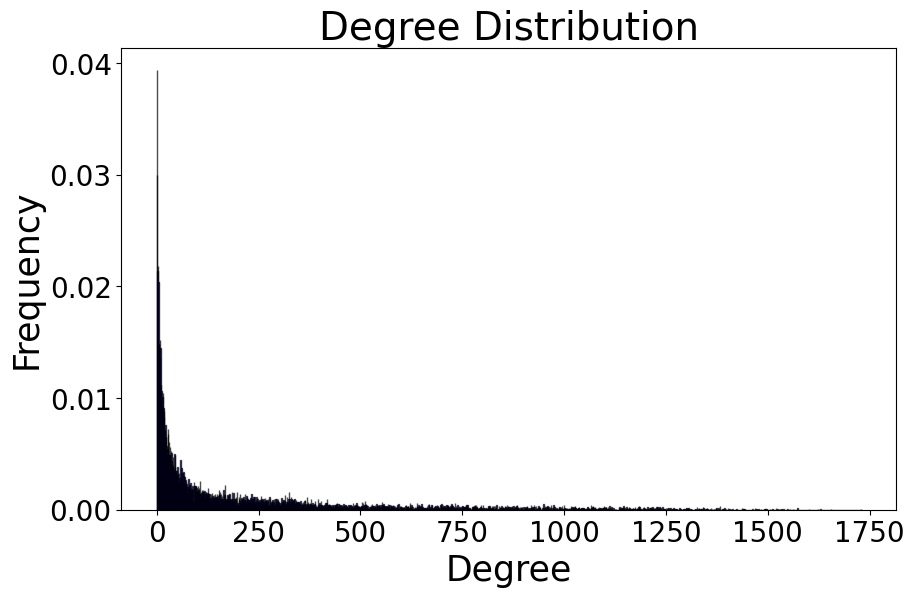

All Pairs Distances:
<class 'list'>
12939X12939


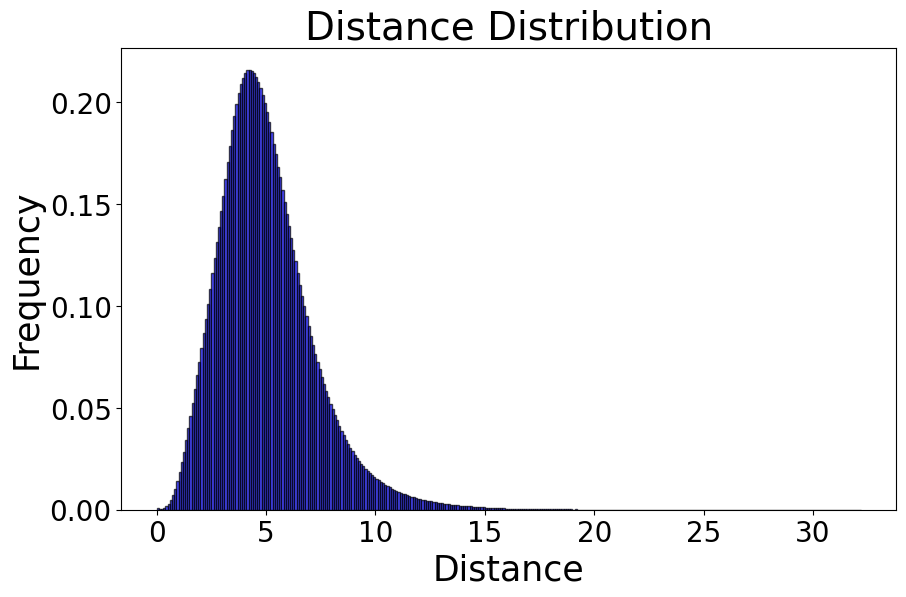

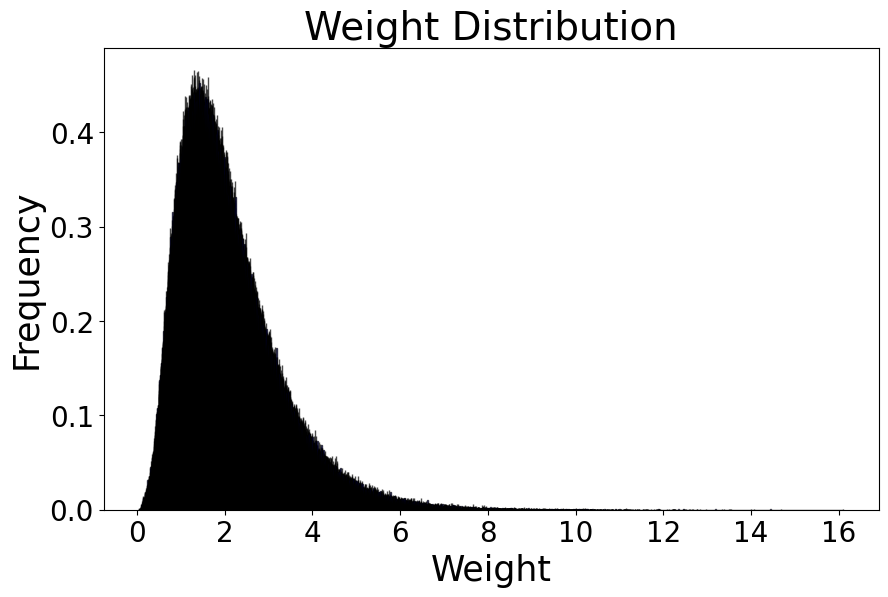

Number of vertices in largest connected component: 12390
Number of edges in largest connected component: 1322541


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,SEPSECS-AS1,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,4.049566,4.054379,3.653362,3.859807,5.439859,3.836151,5.845122,3.948953,4.670290,...,3.761626,12.974239,3.881911,4.843940,5.212416,3.741959,4.342285,3.900542,6.136034,2.182849
DPM1,4.049566,0.000000,4.561088,3.120767,4.202342,5.287102,3.386115,4.906811,4.774663,5.186574,...,3.364626,12.930588,3.893312,4.883592,5.634225,3.353489,4.329942,3.703925,5.009328,3.115051
SCYL3,4.054379,4.561088,0.000000,4.834309,4.760293,6.154686,5.330029,6.661872,4.854599,5.516848,...,4.954138,11.831372,5.602635,6.047238,7.225510,4.216637,5.651799,3.840611,6.455629,3.378663
C1orf112,3.653362,3.120767,4.834309,0.000000,4.487691,4.265392,3.248035,5.027084,5.234163,5.257379,...,2.061395,13.672617,4.290325,5.206391,4.983267,3.127303,3.575942,2.892865,5.538098,3.156659
FGR,3.859807,4.202342,4.760293,4.487691,0.000000,6.077643,4.747050,6.669015,3.644095,4.621543,...,3.809434,13.676288,1.648975,1.601009,4.034362,4.200063,4.539573,4.348429,4.467200,3.930648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,3.741959,3.353489,4.216637,3.127303,4.200063,4.371713,3.204783,5.346206,5.074598,5.008105,...,2.749880,12.821482,4.480568,5.262821,5.305392,0.000000,2.692191,2.697566,3.388063,2.686178
CYB561D2,4.342285,4.329942,5.651799,3.575942,4.539573,4.666147,3.825009,5.765437,5.305107,4.784251,...,3.221815,14.100037,4.959373,5.399013,5.759202,2.692191,0.000000,3.056880,5.224085,3.661792
CCDC7,3.900542,3.703925,3.840611,2.892865,4.348429,3.864123,3.236097,4.932308,5.233182,5.123360,...,2.450357,11.874929,4.656505,5.411186,5.458601,2.697566,3.056880,0.000000,5.126665,3.518130


In [7]:
distance_4S = Nlog_SWIM_pcc_to_distance(pcc_matrix=pcc_4S, fig_path1="./figures/degree_distribution_4S.svg", fig_path2="./figures/distance_distribution_4S.svg", fig_path3="./figures/weight_distribution_4S.svg", pcc_threshold=0.7)
distance_4S.to_csv("distance_4S.csv")
distance_4S

/home/jovyan/work/FUNCTIONS/methods.py:266: RuntimeWarning: divide by zero encountered in log
  nlog = -np.log(non_negative_normalized_pcc)


IGRAPH UNW- 12939 1215109 -- 
+ attr: name (v), weight (e)
graph is connected: False


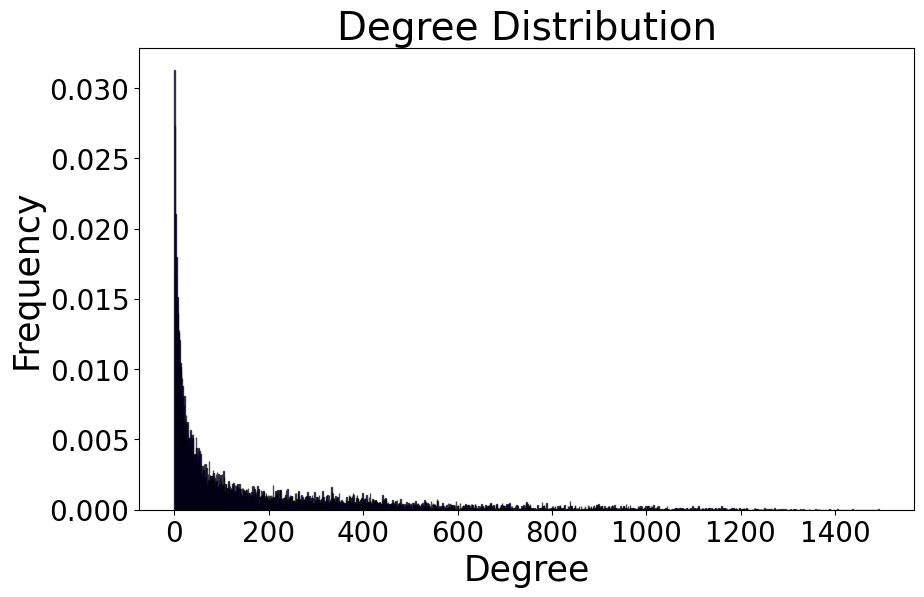

All Pairs Distances:
<class 'list'>
12939X12939


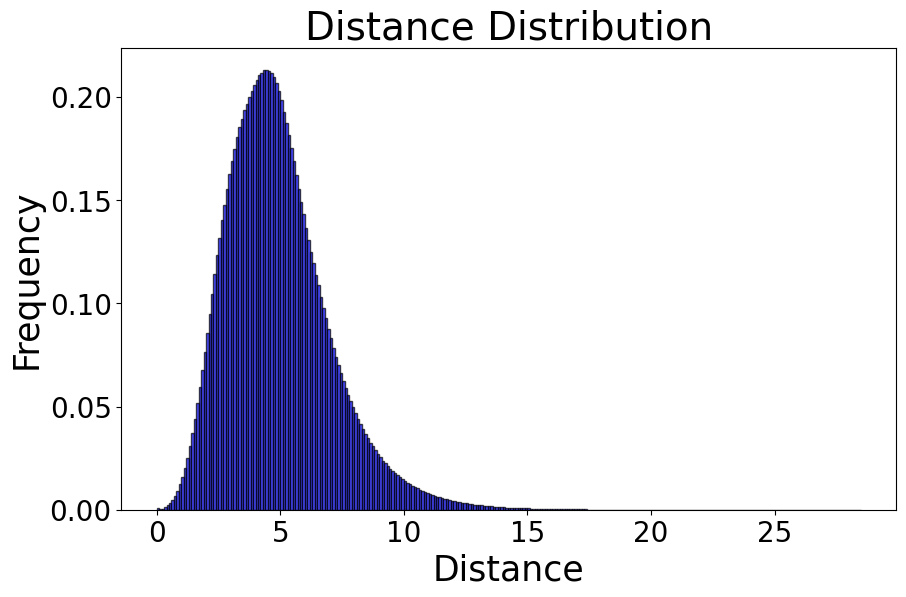

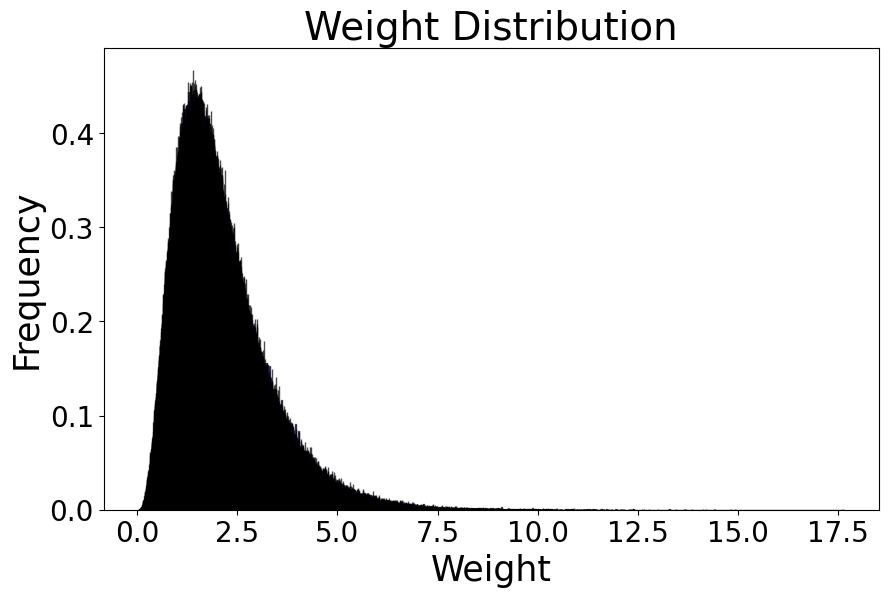

Number of vertices in largest connected component: 12515
Number of edges in largest connected component: 1215099


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,6.747254,6.916494,6.679712,5.320534,6.392583,4.886691,5.035374,7.035969,7.987833,...,7.297138,8.831214,5.123265,5.438491,7.097928,6.142399,7.104581,5.939312,6.648410,5.236430
DPM1,6.747254,0.000000,5.407449,2.624115,5.693078,4.607793,4.288857,4.849912,4.999362,4.849891,...,4.351361,9.008446,5.975841,6.303568,5.105366,3.514022,4.756225,4.000839,3.832724,4.667664
SCYL3,6.916494,5.407449,0.000000,4.111054,5.697785,4.018707,3.909140,3.747442,5.312827,5.419821,...,4.527593,7.117915,5.980548,6.180743,4.824369,3.506496,4.718470,3.393155,4.172948,5.698215
C1orf112,6.679712,2.624115,4.111054,0.000000,4.705757,3.148870,3.564489,3.212960,3.789512,3.390183,...,2.789938,7.582961,4.987027,4.544216,4.595696,2.497763,3.917354,2.835693,3.352868,4.061358
FGR,5.320534,5.693078,5.697785,4.705757,0.000000,4.085837,4.882031,5.196019,3.823196,4.244391,...,5.688789,5.165400,1.353234,1.238207,3.819111,2.410976,3.820729,3.865487,3.063230,5.267048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,6.142399,3.514022,3.506496,2.497763,2.410976,1.868733,3.294803,3.004730,2.081242,2.797618,...,3.785441,5.549042,2.693740,3.021466,4.747025,0.000000,1.603625,1.648383,1.058103,3.049943
CYB561D2,7.104581,4.756225,4.718470,3.917354,3.820729,2.531357,4.186978,4.216704,3.518848,4.276843,...,5.011216,6.997057,4.103492,4.431218,5.965107,1.603625,0.000000,2.844425,2.057658,4.109852
CCDC7,5.939312,4.000839,3.393155,2.835693,3.865487,1.556787,3.372721,3.074524,3.456144,4.351998,...,3.894057,6.860023,4.148250,4.475976,4.689047,1.648383,2.844425,0.000000,2.182891,3.478784


In [8]:
distance_I = Nlog_SWIM_pcc_to_distance(pcc_matrix=pcc_I, fig_path1="./figures/degree_distribution_I.svg", fig_path2="./figures/distance_distribution_I.svg", fig_path3="./figures/weight_distribution_I.svg", pcc_threshold=0.7)
distance_I.to_csv("distance_I.csv")
distance_I

/home/jovyan/work/FUNCTIONS/methods.py:266: RuntimeWarning: divide by zero encountered in log
  nlog = -np.log(non_negative_normalized_pcc)


IGRAPH UNW- 12939 1856546 -- 
+ attr: name (v), weight (e)
graph is connected: False


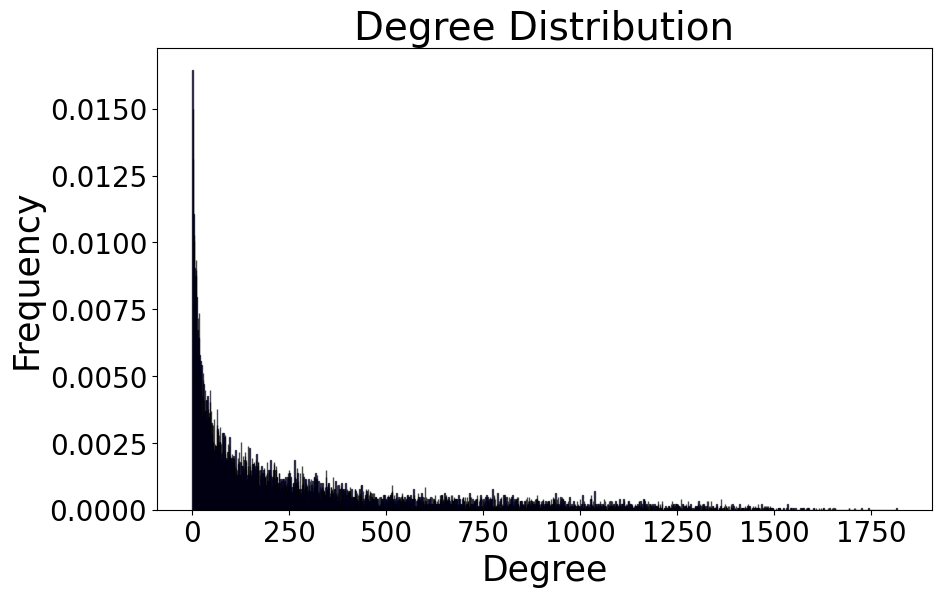

All Pairs Distances:
<class 'list'>
12939X12939


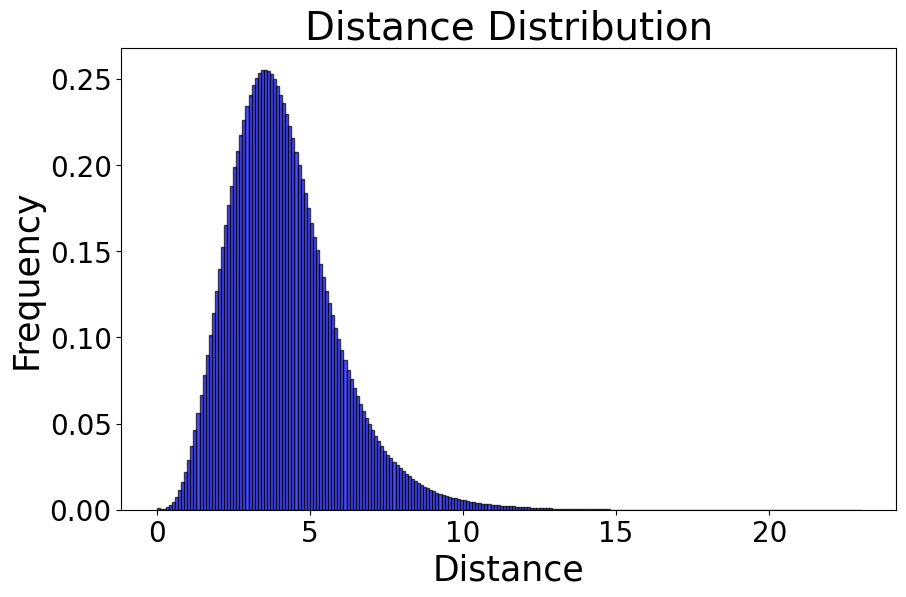

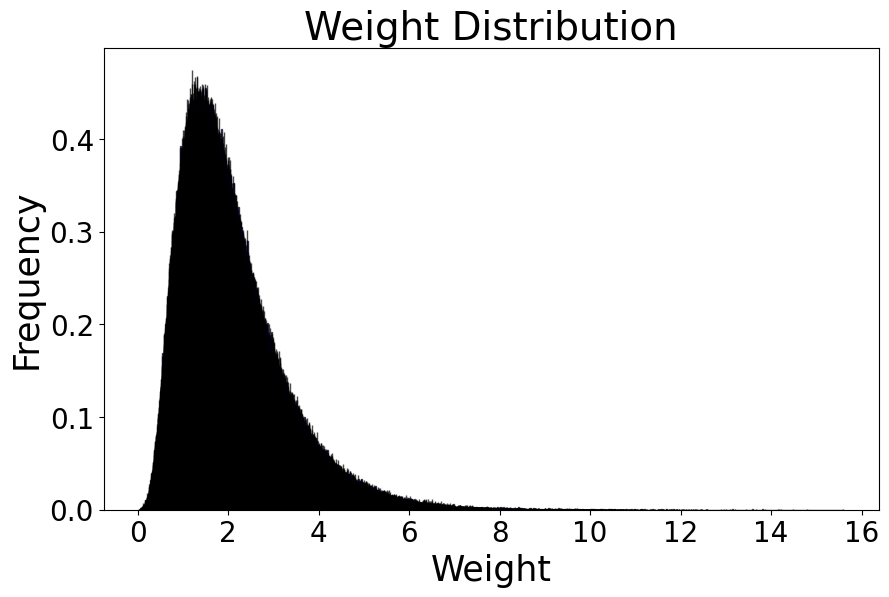

Number of vertices in largest connected component: 12707
Number of edges in largest connected component: 1856535


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,GCLC,NFYA,STPG1,NIPAL3,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,5.902746,2.888415,4.041607,5.513994,3.835461,4.249050,2.680005,2.762740,1.809578,...,6.369465,4.856506,4.799730,5.416101,4.684408,5.747859,9.783209,3.261507,4.809132,3.658073
DPM1,5.902746,0.000000,5.236821,4.465960,7.360267,6.925560,5.532952,6.423844,5.833851,5.588564,...,8.422612,7.134366,6.556012,7.499147,6.414777,7.479279,11.598992,5.620241,7.134573,6.041376
SCYL3,2.888415,5.236821,0.000000,2.452635,3.825150,3.328377,2.517294,3.455411,3.080783,2.524849,...,5.690792,3.423497,3.230003,3.841272,2.815401,4.538623,9.874515,1.906857,3.613285,2.889658
C1orf112,4.041607,4.465960,2.452635,0.000000,4.592470,3.121216,2.322306,3.491492,3.620535,2.299561,...,5.366606,4.799101,3.974921,4.842654,3.348469,5.499416,7.947067,3.067424,4.754663,3.505678
FGR,5.513994,7.360267,3.825150,4.592470,0.000000,5.250867,5.101755,5.684527,5.455299,4.753947,...,8.550961,3.215611,2.214910,1.914176,5.557905,6.356986,9.560271,3.527374,5.982548,4.019820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,5.747859,7.479279,4.538623,5.499416,6.356986,6.653030,5.309669,5.999527,5.713393,5.251378,...,8.809207,6.471775,5.793828,6.624296,6.048580,0.000000,12.568948,5.022104,5.181506,5.032364
CYB561D2,9.783209,11.598992,9.874515,7.947067,9.560271,10.004644,9.758490,9.348559,10.012826,8.745024,...,12.756401,9.846092,8.199929,9.355875,10.864446,12.568948,0.000000,9.866864,11.902567,10.869915
CCDC7,3.261507,5.620241,1.906857,3.067424,3.527374,3.340639,2.954892,3.665045,3.284434,2.728499,...,6.364185,2.787828,2.547796,3.935716,3.655989,5.022104,9.866864,0.000000,4.074122,3.049055


In [9]:
distance_III = Nlog_SWIM_pcc_to_distance(pcc_matrix=pcc_III, fig_path1="./figures/degree_distribution_III.svg", fig_path2="./figures/distance_distribution_III.svg", fig_path3="./figures/weight_distribution_III.svg", pcc_threshold=0.7)
distance_III.to_csv("distance_III.csv")
distance_III

/home/jovyan/work/FUNCTIONS/methods.py:266: RuntimeWarning: divide by zero encountered in log
  nlog = -np.log(non_negative_normalized_pcc)


IGRAPH UNW- 12939 2022063 -- 
+ attr: name (v), weight (e)
graph is connected: False


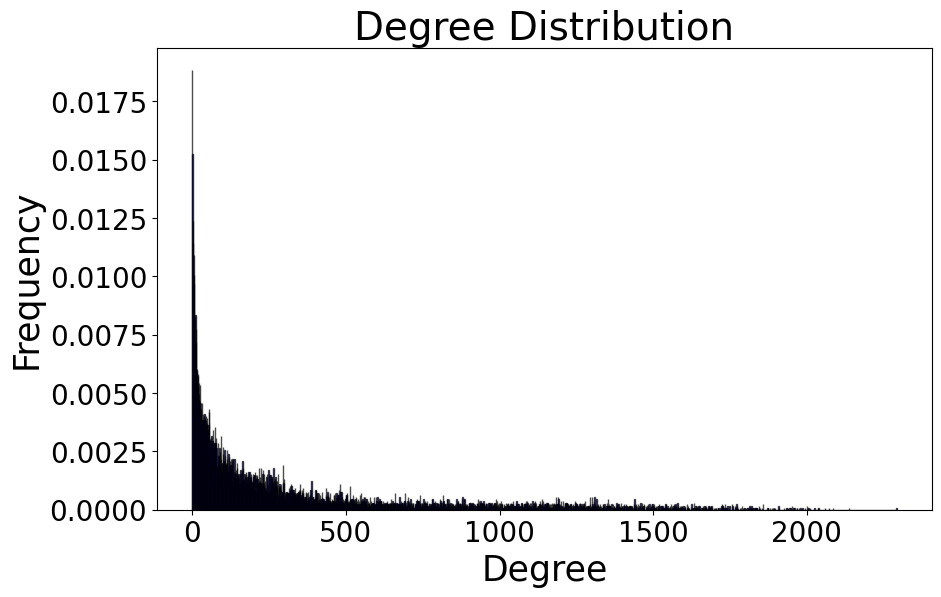

All Pairs Distances:
<class 'list'>
12939X12939


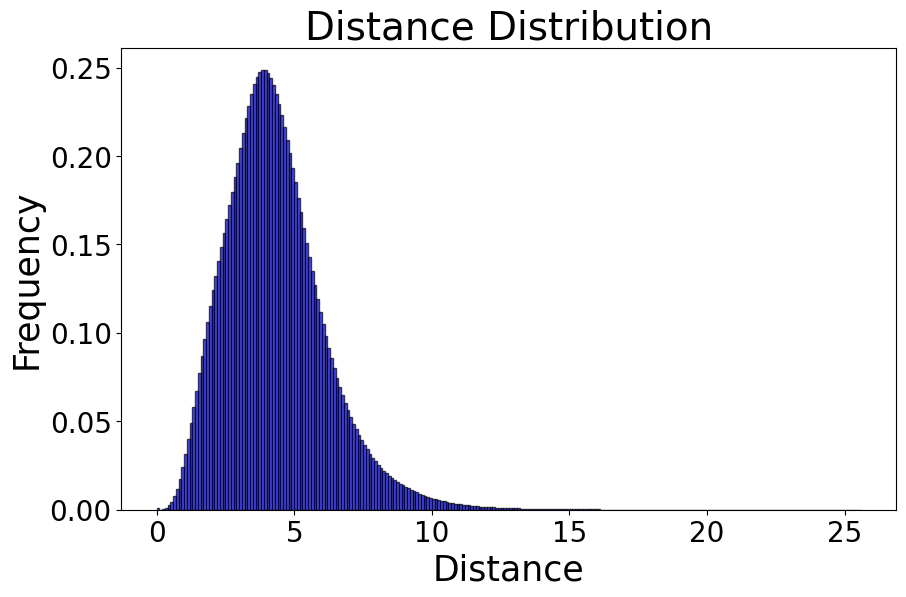

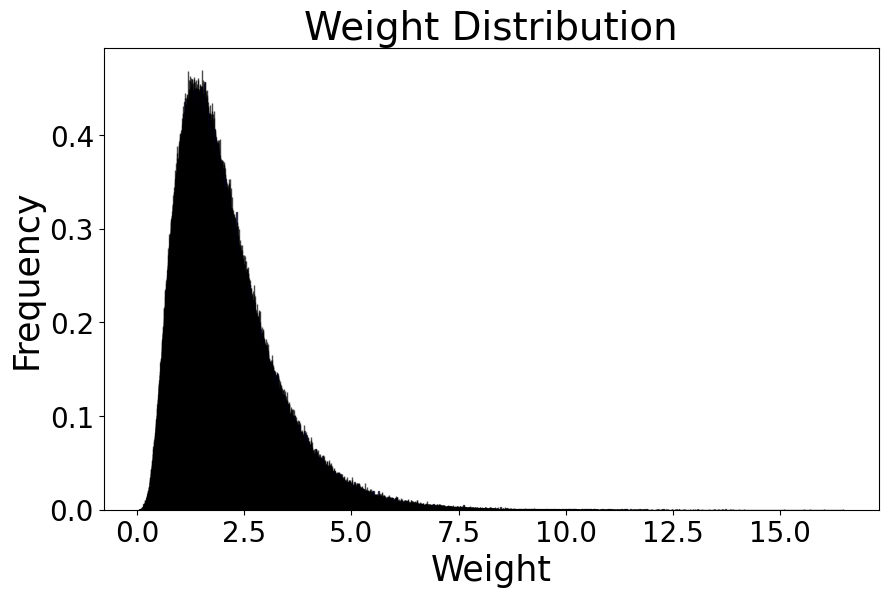

Number of vertices in largest connected component: 12677
Number of edges in largest connected component: 2022053


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,4.347719,3.593492,3.804483,5.412285,4.750681,4.276088,3.066869,6.594232,3.327238,...,4.861320,3.847123,6.383697,6.232782,4.262616,3.711075,3.170238,6.435919,4.177373,1.748688
DPM1,4.347719,0.000000,4.234331,3.774166,6.357230,4.795701,4.375339,3.511375,7.792289,3.847299,...,5.237088,6.014159,5.505786,6.707744,4.627284,3.963984,3.624932,8.286834,3.992703,4.277626
SCYL3,3.593492,4.234331,0.000000,2.456962,4.653973,3.425250,2.484886,1.803583,5.275376,1.859991,...,2.653636,3.860014,5.431115,4.410382,2.441616,2.536041,1.487080,6.702722,2.587127,3.090998
C1orf112,3.804483,3.774166,2.456962,0.000000,4.636730,3.139126,2.267052,1.374009,5.260580,1.143647,...,2.394240,4.215563,5.116416,4.187813,2.737536,2.128126,1.503552,6.478492,2.404926,2.740562
FGR,5.412285,6.357230,4.653973,4.636730,0.000000,5.753884,4.937654,3.883521,7.076003,3.851916,...,4.485925,4.293058,4.337976,1.998103,3.727669,4.534107,3.539184,7.262069,4.520611,3.663596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,3.711075,3.963984,2.536041,2.128126,4.534107,3.151275,3.010192,2.379338,5.356015,1.467046,...,3.385713,3.156511,4.831629,4.117131,3.313069,0.000000,1.188658,5.448659,1.222701,1.962387
CYB561D2,3.170238,3.624932,1.487080,1.503552,3.539184,2.436533,2.194572,1.549920,4.167357,0.586872,...,2.430336,3.628388,5.573337,3.122207,2.612416,1.188658,0.000000,5.687563,1.175162,2.103430
CCDC7,6.435919,8.286834,6.702722,6.478492,7.262069,7.469437,7.270804,6.374089,8.235114,5.935434,...,7.470060,4.376755,8.660835,7.604165,6.692846,5.448659,5.687563,0.000000,5.916947,4.687231


In [10]:
distance_IV = Nlog_SWIM_pcc_to_distance(pcc_matrix=pcc_IV, fig_path1="./figures/degree_distribution_IV.svg", fig_path2="./figures/distance_distribution_IV.svg", fig_path3="./figures/weight_distribution_IV.svg", pcc_threshold=0.7)
distance_IV.to_csv("distance_IV.csv")
distance_IV